## Nettoyage des données 

In [29]:
import sys
sys.path.append(r"C:\Users\GLC\OneDrive\Documents\DATA-IA\Projet1_Nexacom\src\projet1_nexacom")

import pandas as pd
import numpy as np
from data_loader import load_csv
from unidecode import unidecode

# Chargement des fichiers csv à partir de data_loader
df_orders = pd.DataFrame(load_csv(r"C:\Users\GLC\OneDrive\Documents\DATA-IA\Projet1_Nexacom\data\orders.csv"))### Charger les fichiers csv 
df_customers = pd.DataFrame(load_csv(r"C:\Users\GLC\OneDrive\Documents\DATA-IA\Projet1_Nexacom\data\customers.csv"))### Charger les fichiers csv 

#  ORDERS : nettoyage
## Imputation du temps de livraison par la médiane
df_orders["delivery_time_min"] = pd.to_numeric(df_orders["delivery_time_min"], errors="coerce")
médiane_durée = df_orders['delivery_time_min'].median()
print(f'Médiane durée : {médiane_durée:.1f} min')
df_orders['delivery_time_min'] = df_orders['delivery_time_min'].fillna(médiane_durée)
print(f'NaN restants : {df_orders["delivery_time_min"].isnull().sum()}')

## Normalisation des Dates
df_orders["order_date"] = pd.to_datetime(df_orders["order_date"], format="mixed", dayfirst=True)

## Ville normalisée
df_orders["city"] = df_orders["city"].str.strip().str.title().apply(unidecode)

## Suppresion des espaces et minuscules pour les statuts
df_orders["status"] = df_orders["status"].str.strip().str.lower()

## Remplacer les valeurs manquantes des produits par Inconnu
df_orders["product_category"] = df_orders["product_category"].fillna("Inconnu")

## Convertir total_amount_xaf en numérique
df_orders["total_amount_xaf"] = pd.to_numeric(df_orders["total_amount_xaf"], errors="coerce")

# NettoyaGe de CUSTOMERS
## Ville normalisée
df_customers["city"] = df_customers["city"].str.strip().str.title().apply(unidecode)

## Mettre les loyalty_score supérieur à 100 à 100
df_customers["loyalty_score"] = pd.to_numeric(df_customers["loyalty_score"], errors="coerce")
df_customers["loyalty_score"] = df_customers["loyalty_score"].clip(upper=100)

## Normalisation numéros de téléphone au format 6XXXXXXXX
def normalize_phone(phone):
    if pd.isna(phone):
        return None
    phone = str(phone).replace(" ", "").replace("-", "")
    if phone.startswith("+237"):
        phone = phone[4:]
    elif phone.startswith("237"):
        phone = phone[3:]
    return phone

df_customers["phone"] = df_customers["phone"].apply(normalize_phone)

## Déduplication : garder le dernier enregistrement par téléphone
df_customers = df_customers.drop_duplicates(subset="phone", keep="last")

## Convertir registration_date en datetime
df_customers["registration_date"] = pd.to_datetime(df_customers["registration_date"], format="mixed", dayfirst=True, errors="coerce")

print(f"Orders : {len(df_orders)} lignes")
print(f"Customers uniques : {len(df_customers)} lignes")
print(f"NaN delivery_time_min restants : {df_orders['delivery_time_min'].isnull().sum()}")

Médiane durée : 45.7 min
NaN restants : 0
Orders : 12500 lignes
Customers uniques : 2178 lignes
NaN delivery_time_min restants : 0


## Feature Engineering

In [44]:
df_orders["order_hour"] = df_orders["order_date"].dt.hour
df_orders["order_day"] = df_orders["order_date"].dt.day_name()
df_orders["order_month"] = df_orders["order_date"].dt.to_period("M")

# Merge avec customers
df = df_orders.merge(df_customers, on="customer_id", how="left", suffixes=("_order", "_customer"))

# Client actif a commandé au moins 2 fois
commandes_par_client = df.groupby("customer_id")["order_id"].count()
clients_actifs = commandes_par_client[commandes_par_client >= 2].index
df["client_actif"] = df["customer_id"].isin(clients_actifs)

print(f"Clients actifs : {df['client_actif'].sum()} commandes")
print(f"Clients inactifs : {(~df['client_actif']).sum()} commandes")

Clients actifs : 12165 commandes
Clients inactifs : 335 commandes


## Visualisation

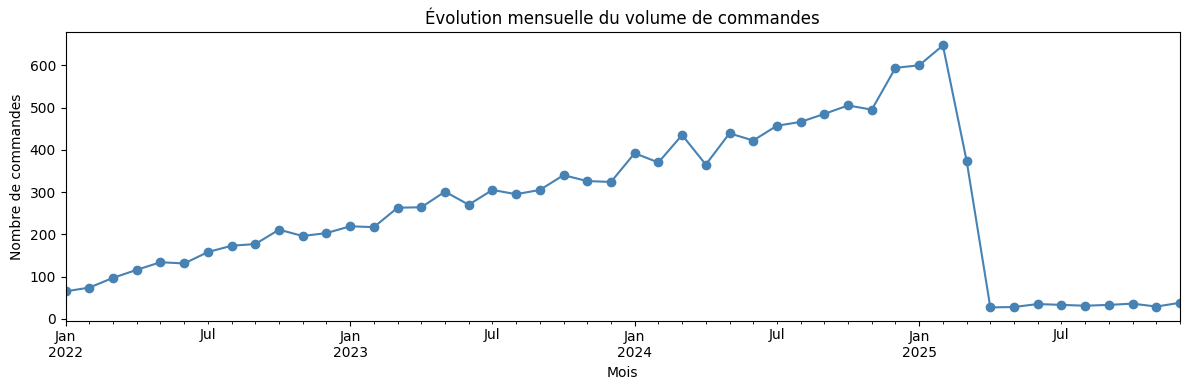

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 4))
Evo_Mens = df.groupby("order_month")["order_id"].count()
Evo_Mens.plot(ax=ax, marker="o", color="steelblue")
ax.set_title("Évolution mensuelle du volume de commandes")
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de commandes")
plt.tight_layout()
plt.savefig("commandes.png", dpi=150)
plt.show()

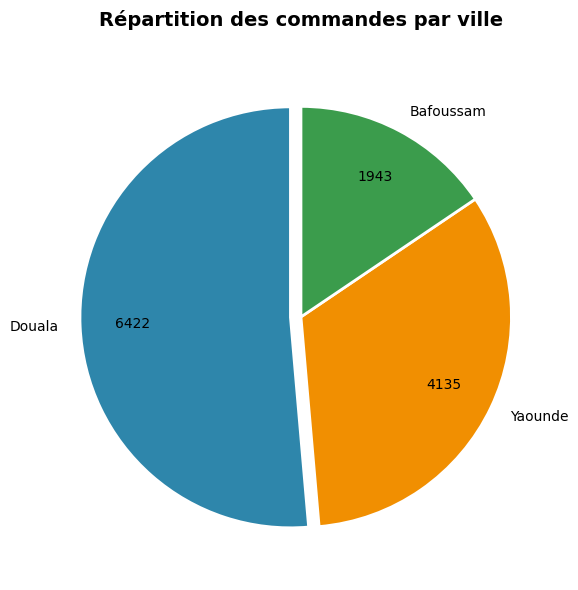

In [9]:
repartition = df["city_order"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    repartition.values,
    labels=repartition.index,
    colors = ['#2E86AB', '#F18F01', '#3B9C4C'],
    startangle=90, pctdistance=0.75,
    explode=(0.05, 0, 0),
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    autopct=lambda pct: f"{int(round(pct / 100 * sum(repartition.values)))}"
)
ax.set_title("Répartition des commandes par ville", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()



In [6]:
Nbre_retard = df.groupby("city_order").apply(lambda x: (x["status"] == "en_retard").sum() )
print (Nbre_retard)


city_order
Bafoussam     403
Douala       1303
Yaounde       916
dtype: int64


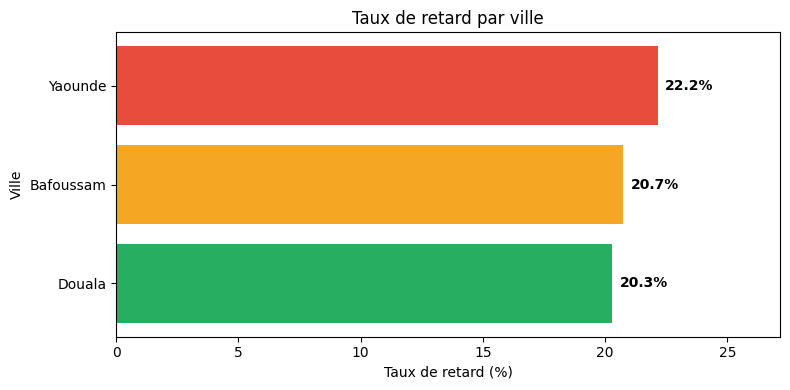

In [47]:
taux_retard = df.groupby("city_order").apply(
    lambda x: (x["status"] == "en_retard").sum() / len(x) * 100
).sort_values(ascending=True) 

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(taux_retard.index, taux_retard.values,
               color=["#27AE60", "#F5A623", "#E74C3C"])  # 

# Afficher le % au bout de chaque barre
for bar, val in zip(bars, taux_retard.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")

ax.set_title("Taux de retard par ville")
ax.set_xlabel("Taux de retard (%)")
ax.set_ylabel("Ville")
ax.set_xlim(0, taux_retard.max() + 5) 
plt.tight_layout()
plt.show()



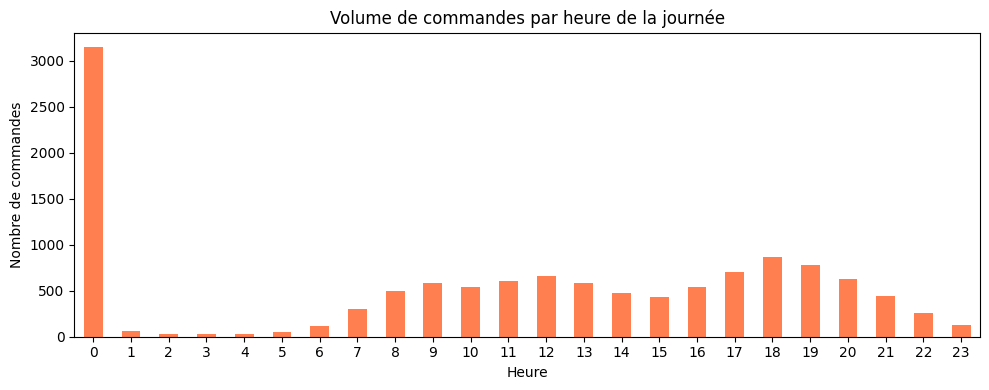

In [48]:
fig, ax = plt.subplots(figsize=(10, 4))
df["order_hour"].value_counts().sort_index().plot(kind="bar",
    ax=ax, color="coral")
ax.set_title("Volume de commandes par heure de la journée")
ax.set_xlabel("Heure")
ax.set_ylabel("Nombre de commandes")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("volume_par_heure.png", dpi=150)
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_12348\274192106.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


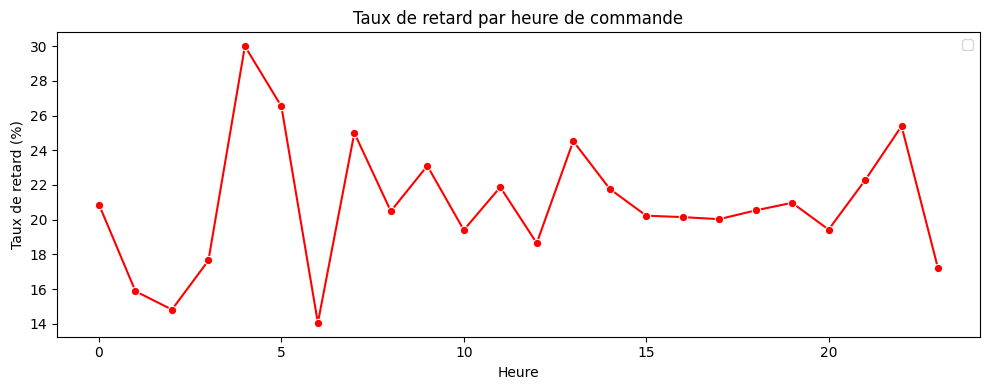

In [13]:
retard_heure = df.groupby("order_hour").apply(
    lambda x: (x["status"] == "en_retard").sum() / len(x) * 100
).reset_index(name="taux_retard_%")

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=retard_heure, x="order_hour", y="taux_retard_%",
             marker="o", color="red", ax=ax)
ax.set_title("Taux de retard par heure de commande")
ax.set_xlabel("Heure")
ax.set_ylabel("Taux de retard (%)")
ax.legend()
plt.tight_layout()
plt.savefig("taux_de_retard.png", dpi=150)
plt.show()

In [49]:
# 1. Normaliser : minuscule + suppression espaces avant/après + suppression underscores
df_orders["product_category"] = (
    df_orders["product_category"]
    .str.lower()
    .str.strip()
    .str.replace("_", " ", regex=False)
)

# 2. Vérifier les valeurs uniques restantes AVANT de mapper
print(df_orders["product_category"].unique())

# 3. Mapper seulement les fautes de frappe / synonymes restants
mapping_cat = {
    "électroniques": "electronique",
    "électronique": "electronique",
    "vetements": "vetement",
    "vétements": "vetement",
    "vêtements": "vetement",
    "articles ménagers": "articles menagers",
    "pharmcie": "pharmacie",
    "resaturation": "restauration",
    "restaurant": "restauration",
    "boisssons": "boisson",
    "boissons": "boisson",
    "produits frais": "produit frais",
    "epiceries": "epicerie",
    "épicerie": "epicerie",
    "épicérie": "epicerie",
    "papeteries": "papeterie",
    "hygienes": "hygiene",
    "hygiène": "hygiene",
    "hygiéne": "hygiene",
    "cosmetiques": "cosmetique",
    "cosmétiques": "cosmetique",
    "": "inconnu",
}
df_orders["product_category"] = df_orders["product_category"].replace(mapping_cat)

# 4. Vérifier le résultat final
print(df_orders["product_category"].unique())
print(df_orders["product_category"].isna().sum())

<StringArray>
[          'inconnu',      'restauration',          'epicerie',
          'vetement',           'hygiene',      'electronique',
           'boisson', 'articles menagers',     'produit frais',
        'cosmetique',         'papeterie',         'pharmacie']
Length: 12, dtype: str
<StringArray>
[          'inconnu',      'restauration',          'epicerie',
          'vetement',           'hygiene',      'electronique',
           'boisson', 'articles menagers',     'produit frais',
        'cosmetique',         'papeterie',         'pharmacie']
Length: 12, dtype: str
0


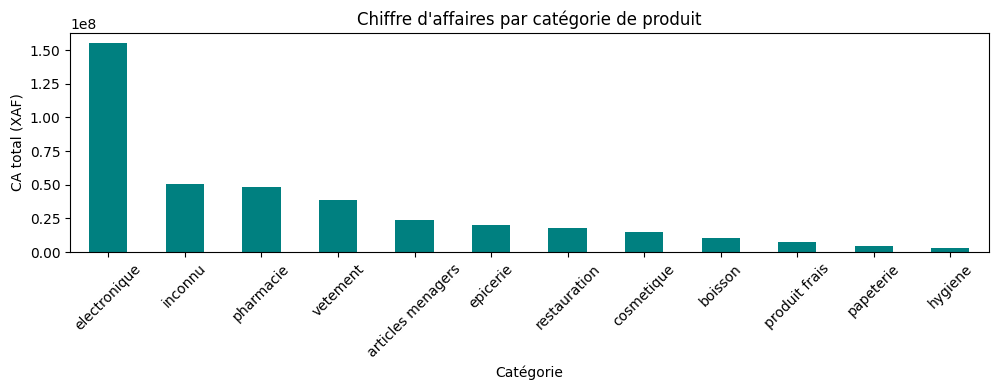

In [45]:
ca_cat = df.groupby("product_category")["total_amount_xaf"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ca_cat.plot(kind="bar", ax=ax, color="teal")
ax.set_title("Chiffre d'affaires par catégorie de produit")
ax.set_xlabel("Catégorie")
ax.set_ylabel("CA total (XAF)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

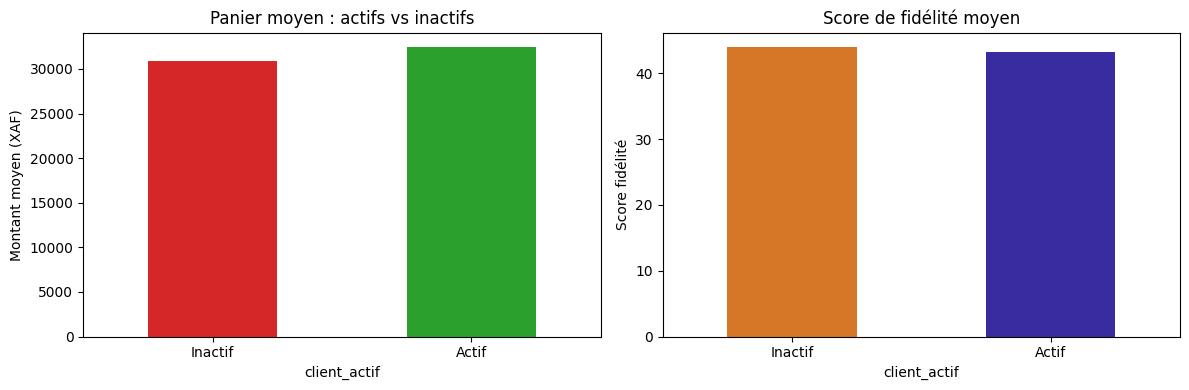

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panier moyen
df.groupby("client_actif")["total_amount_xaf"].mean().plot(
    kind="bar", ax=axes[0], color=["#d62728", "#2ca02c"])
axes[0].set_title("Panier moyen : actifs vs inactifs")
axes[0].set_xticklabels(["Inactif", "Actif"], rotation=0)
axes[0].set_ylabel("Montant moyen (XAF)")

# Score fidélité
df.groupby("client_actif")["loyalty_score"].mean().plot(
    kind="bar", ax=axes[1], color=["#d67627", "#382ca0"])
axes[1].set_title("Score de fidélité moyen")
axes[1].set_xticklabels(["Inactif", "Actif"], rotation=0)
axes[1].set_ylabel("Score fidélité")

plt.tight_layout()
plt.savefig("fidelity.png", dpi=150)
plt.show()

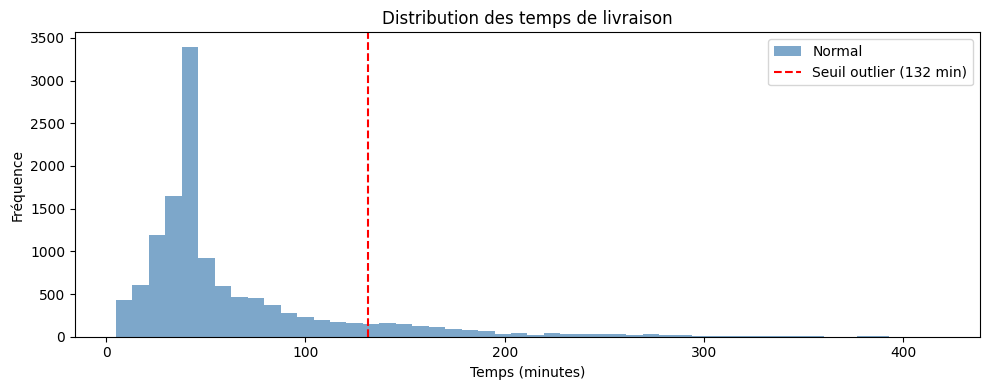

In [7]:
Q1 = df["delivery_time_min"].quantile(0.25)
Q3 = df["delivery_time_min"].quantile(0.75)
Borne_Sup = Q3 + 1.5 * (Q3 - Q1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["delivery_time_min"].dropna(), bins=50,
        color="steelblue", alpha=0.7, label="Normal")
ax.axvline(Borne_Sup, color="red", linestyle="--",
           label=f"Seuil outlier ({Borne_Sup:.0f} min)")
ax.set_title("Distribution des temps de livraison")
ax.set_xlabel("Temps (minutes)")
ax.set_ylabel("Fréquence")
ax.legend()
plt.tight_layout()
plt.savefig("distibution.png", dpi=150)
plt.show()

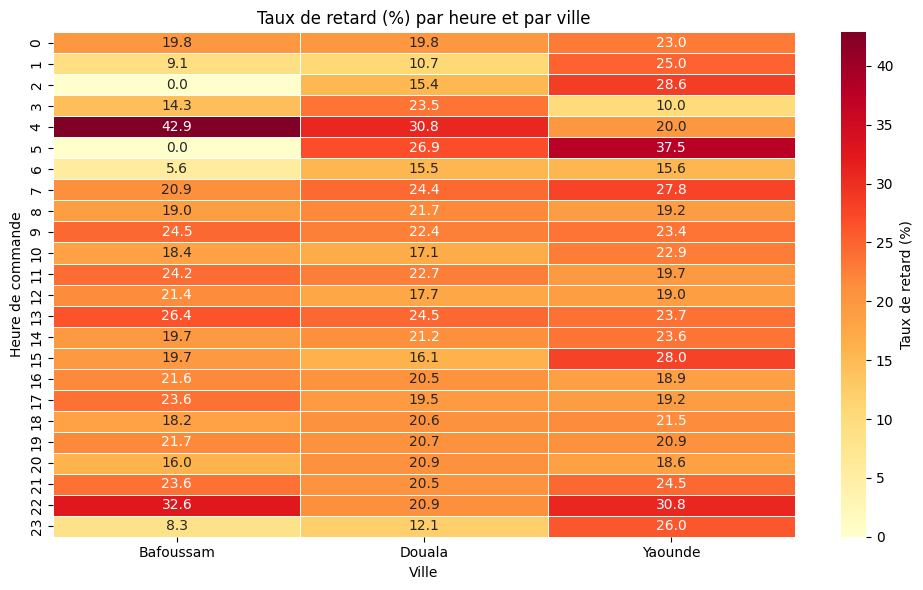

In [11]:
# Calcul du taux de retard pour chaque combinaison heure × ville
heatmap_data = df.groupby(["order_hour", "city_order"]).apply(
    lambda x: (x["status"] == "en_retard").sum() / len(x) * 100
).unstack(level="city_order")

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={"label": "Taux de retard (%)"}
)
ax.set_title("Taux de retard (%) par heure et par ville")
ax.set_xlabel("Ville")
ax.set_ylabel("Heure de commande")
plt.tight_layout()
plt.show()

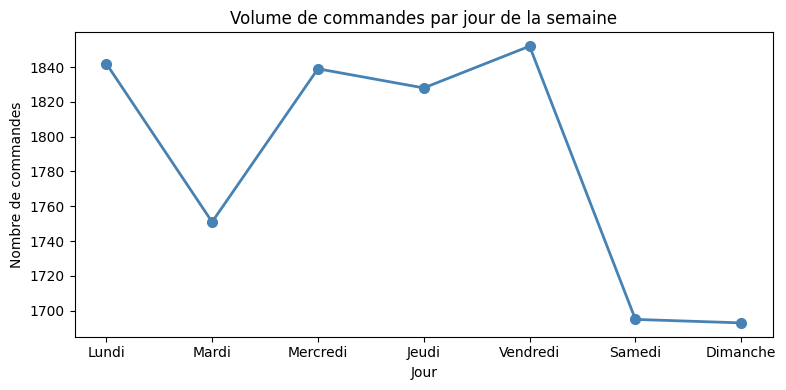

In [10]:
ordre_jours = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
labels_fr   = ["Lundi","Mardi","Mercredi","Jeudi","Vendredi","Samedi","Dimanche"]

volume_jour = df["order_day"].value_counts().reindex(ordre_jours)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(labels_fr, volume_jour.values, marker="o", color="steelblue", linewidth=2, markersize=7)
ax.set_title("Volume de commandes par jour de la semaine")
ax.set_xlabel("Jour")
ax.set_ylabel("Nombre de commandes")
plt.tight_layout()
plt.show()

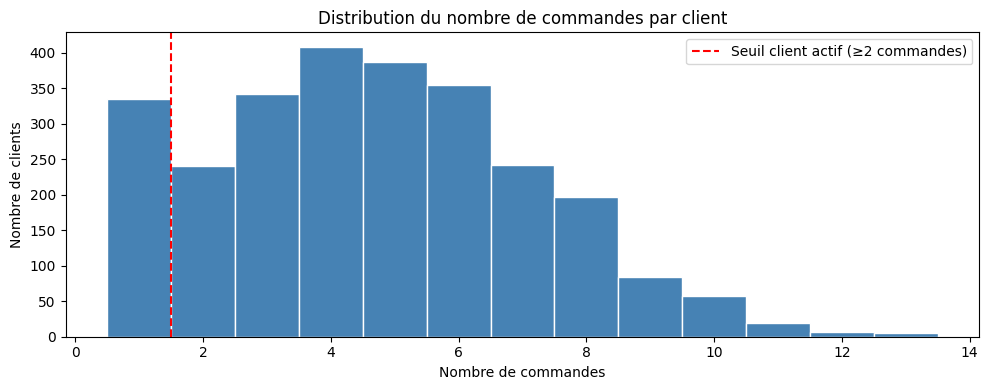

In [12]:
commandes_par_client = df.groupby("customer_id")["order_id"].count()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(commandes_par_client.values, bins=range(1, commandes_par_client.max() + 2),
        color="steelblue", edgecolor="white", align="left")
ax.set_title("Distribution du nombre de commandes par client")
ax.set_xlabel("Nombre de commandes")
ax.set_ylabel("Nombre de clients")
ax.axvline(x=1.5, color="red", linestyle="--", label="Seuil client actif (≥2 commandes)")
ax.legend()
plt.tight_layout()
plt.show()

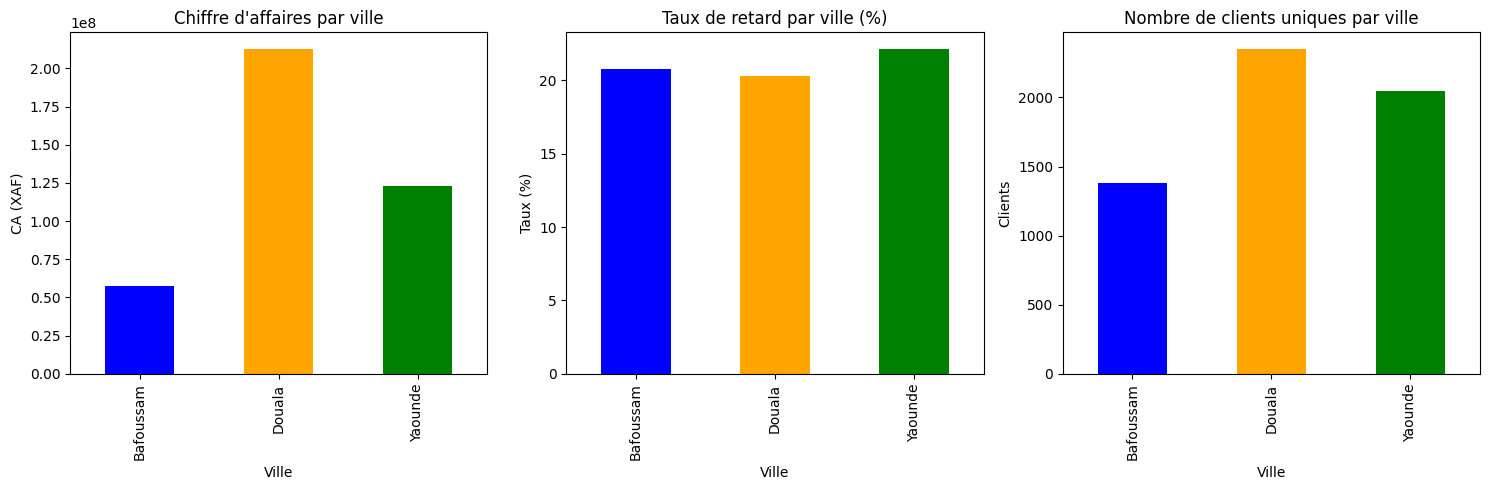

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# CA par ville
df_orders.groupby("city")["total_amount_xaf"].sum().plot(
    kind="bar", ax=axes[0], color=["blue", "orange", "green"]
)
axes[0].set_title("Chiffre d'affaires par ville")
axes[0].set_xlabel("Ville")
axes[0].set_ylabel("CA (XAF)")

# Taux de retard par ville
retard = df_orders.groupby("city").apply(
    lambda x: (x["status"] == "en_retard").sum() / len(x) * 100
)
retard.plot(kind="bar", ax=axes[1], color=["blue", "orange", "green"])
axes[1].set_title("Taux de retard par ville (%)")
axes[1].set_xlabel("Ville")
axes[1].set_ylabel("Taux (%)")

# Nombre de clients par ville
df_orders.groupby("city")["customer_id"].nunique().plot(
    kind="bar", ax=axes[2], color=["blue", "orange", "green"]
)
axes[2].set_title("Nombre de clients uniques par ville")
axes[2].set_xlabel("Ville")
axes[2].set_ylabel("Clients")

plt.tight_layout()
plt.show()

## Les Insights

In [ ]:

# Insight 1 : Taux de retard global
taux_global = (df["status"] == "en_retard").sum() / len(df) * 100
print(f"INSIGHT 1 : Taux de retard global = {taux_global:.1f}%")

# Insight 2 : Commandes après 20h plus risquées
apres_20h = df[df["order_hour"] >= 20]
taux_retard_20h = (apres_20h["status"] == "en_retard").sum() / len(apres_20h) * 100
print(f"INSIGHT 2 : Taux de retard après 20h = {taux_retard_20h:.1f}% vs {taux_global:.1f}% global")

# Insight 3 : Ville la plus performante
print(f"INSIGHT 3 : Ville avec le moins de retards =", taux_retard["city_order"].iloc[taux_retard["taux_retard_%"].idxmin()])

# Insight 4 : Catégorie la plus rentable
print(f"INSIGHT 4 : Catégorie la plus rentable = {ca_cat.idxmax()} ({ca_cat.max():,.0f} XAF)")

# Insight 5 : Différence panier actifs vs inactifs
panier_actif = df[df["client_actif"]]["total_amount_xaf"].mean()
panier_inactif = df[~df["client_actif"]]["total_amount_xaf"].mean()
print(f"INSIGHT 5 : Les clients actifs dépensent {panier_actif/panier_inactif:.1f}x plus que les inactifs")

INSIGHT 1 : Taux de retard global = 21.0%
INSIGHT 2 : Taux de retard après 20h = 21.1% vs 21.0% global
INSIGHT 3 : Ville avec le moins de retards = Douala
INSIGHT 4 : Catégorie la plus rentable = electronique (55,706,538 XAF)
INSIGHT 5 : Les clients actifs dépensent 1.0x plus que les inactifs


In [20]:
# Après tout le nettoyage et le merge
df_orders.to_csv("orders_clean.csv", index=False)

df_customers.to_csv("customers_clean.csv", index=False)

df.to_csv("df_merged_clean.csv", index=False)
